<a href="https://colab.research.google.com/github/burakayy7/WildFire-prediction/blob/main/WildFire_Model_Train_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [ ]:
# !pip install tensorflow

# Get Training Data

In [ ]:
!git clone https://github.com/burakayy7/wildfire_data.git

Cloning into 'wildfire_data'...
remote: Enumerating objects: 8016, done.
remote: Counting objects: 100% (8016/8016), done.
remote: Compressing objects: 100% (8014/8014), done.
remote: Total 8016 (delta 3), reused 8011 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (8016/8016), 19.57 MiB | 9.83 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (8005/8005), done.


# Train

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Parameters
# -----------------------------
DATA_DIR = "/content/wildfire_data/accurate_fire_dataset_v2"  # folder with CSVs
SEQ_LEN = 10  # use last 10 timesteps (5 min window)
SENSORS = ["temp_C", "humidity_%", "co2_ppm"]

# -----------------------------
# Load data
# -----------------------------
def load_dataset(data_dir, seq_len=10):
    X_list = []
    y_list = []
    csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".csv") and f != "metadata.csv"])

    for f in csv_files:
        df = pd.read_csv(os.path.join(data_dir, f))
        # select the last SEQ_LEN rows for features
        features = df[SENSORS].values[-seq_len:, :]
        X_list.append(features)
        # label is the same for the entire sample
        y_list.append(int(df["label"].iloc[0]))

    X = np.stack(X_list)
    y = np.array(y_list)
    return X, y

X, y = load_dataset(DATA_DIR, seq_len=SEQ_LEN)
print("X shape:", X.shape)  # (num_samples, SEQ_LEN, 3)
print("y shape:", y.shape)

# -----------------------------
# Train / validation / test split
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# -----------------------------
# Build TinyML-friendly model
# -----------------------------
model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(SENSORS))),
    layers.Conv1D(16, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(32, kernel_size=3, activation='relu'),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)

# -----------------------------
# Test & evaluation
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))




X shape: (3000, 10, 3)
y shape: (3000,)
Train: 2160, Val: 540, Test: 300


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 16)          │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5825 - loss: 1.2697 - val_accuracy: 0.6759 - val_loss: 0.5927
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7225 - loss: 0.5728 - val_accuracy: 0.7296 - val_loss: 0.5093
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7436 - loss: 0.4699 - val_accuracy: 0.6963 - val_loss: 0.7293
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7717 - loss: 0.4694 - val_accuracy: 0.7611 - val_loss: 0.4477
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7941 - loss: 0.4513 - val_accuracy: 0.7222 - val_loss: 0.6024
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7809 - loss: 0.4525 - val_accuracy: 0.7259 - val_loss: 0.5591
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7796 - loss: 0.4378 - val_accuracy: 0.7611 - val_loss: 0.4954
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.3915 - val_accuracy: 0.

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf

SEQ_LEN = 60        # matches Arduino buffer
FEATURES = ["temp_C", "humidity_%", "co2_ppm"]

DATA_DIR = "/content/wildfire_data/accurate_fire_dataset_v3"  # folder containing CSVs

def load_dataset(data_dir=DATA_DIR, seq_len=SEQ_LEN):
    X_list, y_list = [], []
    csv_files = sorted([f for f in os.listdir(data_dir)
                        if f.endswith(".csv") and f.startswith("sample_")])

    for f in csv_files:
        df = pd.read_csv(os.path.join(data_dir, f))

        # ensure correct columns
        for col in ["temp_C", "humidity_%", "co2_ppm"]:
            if col not in df.columns:
                raise ValueError(f"Missing column {col} in {f}")

        # ensure sequence length is exactly 60
        if df.shape[0] != seq_len:
            raise ValueError(
                f"Sequence in {f} has {df.shape[0]} steps, expected {seq_len}.\n"
                f"Fix your generator or your SEQ_LEN."
            )

        X_list.append(df[["temp_C", "humidity_%", "co2_ppm"]].values)
        y_list.append(int(df["label"].iloc[0]))

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list).astype(np.float32)
    return X, y



# -----------------------------
# Load dataset
# -----------------------------
X, y = load_dataset()
print("X shape:", X.shape)  # should be (num_samples, 60, 3)
print("y shape:", y.shape)

# -----------------------------
# Train / validation / test split
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# -----------------------------
# Build TinyML-friendly model
# -----------------------------
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(FEATURES), 1)),  # (60, 3, 1)

    # First small Conv2D layer
    layers.Conv2D(4, (4, 3), padding='same', activation='relu'),  # (60, 1, 4)
    layers.MaxPool2D((4, 1)),  # (15, 1, 4)

    # Second Conv2D layer
    layers.Conv2D(8, (4, 1), padding='same', activation='relu'),  # (15, 1, 8)
    layers.MaxPool2D((3, 1), padding='same'),  # (5, 1, 8)

    # Flatten + tiny dense layers
    layers.Flatten(),  # (40,)
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)
# -----------------------------
# Test & evaluation
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

FileNotFoundError: [Errno 2] No such file or directory: '/content/wildfire_data/accurate_fire_dataset_v3'

In [ ]:
idx = 16
vals = X_test[idx]

print("Phase:", y_test[idx])   # 0 or 1

print("float test_sample[60][3] = {")
for row in vals:
    print("    {" + ", ".join(f"{v:.2f}" for v in row) + "},")
print("};")

Phase: 1.0
float test_sample[60][3] = {
    {23.60, 57.87, 421.22},
    {23.66, 57.57, 423.68},
    {23.62, 57.65, 423.30},
    {23.66, 57.57, 422.27},
    {23.67, 57.58, 421.50},
    {23.65, 57.51, 421.40},
    {23.71, 57.29, 421.04},
    {23.69, 57.15, 421.69},
    {23.67, 57.42, 421.62},
    {23.68, 57.46, 420.88},
    {23.57, 57.96, 423.32},
    {23.56, 58.20, 422.58},
    {23.59, 58.23, 422.30},
    {23.61, 58.19, 422.27},
    {23.56, 58.10, 425.62},
    {23.55, 57.99, 425.25},
    {23.57, 58.04, 425.94},
    {23.59, 58.06, 425.48},
    {23.61, 58.01, 425.57},
    {23.67, 57.80, 425.23},
    {23.69, 57.65, 424.15},
    {23.67, 57.81, 423.61},
    {23.68, 57.87, 423.09},
    {23.77, 57.62, 423.80},
    {23.85, 57.28, 423.20},
    {23.86, 57.13, 423.82},
    {23.85, 57.27, 424.86},
    {23.95, 56.68, 426.22},
    {23.98, 56.38, 429.76},
    {23.90, 56.54, 432.02},
    {23.83, 56.74, 430.03},
    {23.86, 56.44, 431.41},
    {23.96, 56.14, 428.53},
    {24.11, 55.96, 431.51},
    {24.

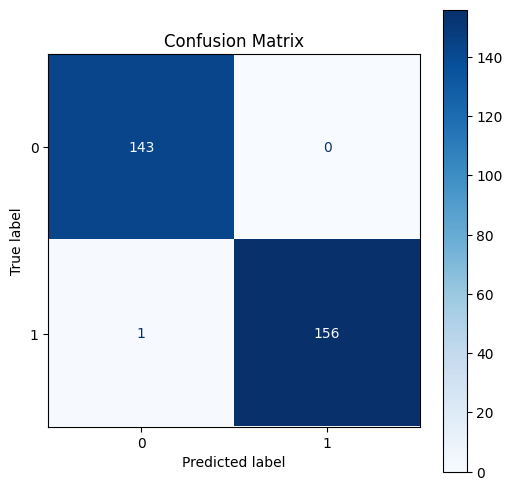

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

# Create a ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# -----------------------------
# Convert to TensorFlow Lite
# -----------------------------
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# tflite_model = converter.convert()


converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.experimental_new_converter = True
converter.optimizations = []     # disable quantization
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]
tflite_model = converter.convert()

with open("wildfire_onset_model.tflite", "wb") as f:
    f.write(tflite_model)
print("TFLite model saved as wildfire_onset_model.tflite")

Saved artifact at '/tmp/tmpi3qx7am6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 3, 1), dtype=tf.float32, name='keras_tensor_49')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140695458027792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695458025488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440878160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440871440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440876816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440870096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440883536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140695440869712: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved as wildfire_onset_model.tflite


In [ ]:
!apt-get -qq install xxd
# Save the file as a C source file
!xxd -i /content/wildfire_onset_model.tflite > /content/model.cc
# Print the source file
!cat /content/model.cc

unsigned char _content_wildfire_onset_model_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00, 0x98, 0x14, 0x00, 0x00,
  0xa8, 0x14, 0x00, 0x00, 0xf0, 0x1e, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x76, 0xea, 0xff, 0xff,
  0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00, 0x3c, 0x00, 0x00, 0x00,
  0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76, 0x69, 0x6e, 0x67, 0x5f,
  0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x90, 0xff, 0xff, 0xff, 0x11, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00, 0x6f, 0x75, 0x74, 0x70,
  0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00,
  0x04, 0x00, 0x00, 0x00, 0x0a, 0xec, 0xff, 0xff, 0x04,